# MG LeJEPA v2 augmentation visualization

This notebook visualizes the current `mg_lejepa_aug_v2.json` policy on MG mammography images.

In [1]:
from __future__ import annotations

import ast
import json
import math
import random
from pathlib import Path
from typing import Any, Optional

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from torchvision.transforms import InterpolationMode, RandomResizedCrop
import torchvision.transforms.functional as TF

# -----------------------------
# Editable paths / parameters
# -----------------------------

FULL_CSV = Path("/pfss/mlde/workspaces/mlde_wsp_PI_Roig/shared/datasets/breastTumor/mg/mg-only-all.csv")
BIN_PATH = Path("/pfss/mlde/workspaces/mlde_wsp_PI_Roig/shared/datasets/breastTumor/mg/mg-only-all.bin")
AUG_CONFIG = Path("/pfss/mlde/workspaces/mlde_wsp_PI_Roig/luis/mg_lejepa_aug_v4.json")

# Prefer the debug train split so examples match the current training setting.
# Set SPLIT_CSV = FULL_CSV if you want to sample from all MG rows.
SPLIT_CSV = Path("/pfss/mlde/workspaces/mlde_wsp_PI_Roig/shared/datasets/breastTumor/mg/debug-split/mg_debug_30k_balanced_train.csv")

IMAGE_HEIGHT = 512
IMAGE_WIDTH = 512
MEMMAP_DTYPE = "uint16"
SEED = 42

# Display defaults. You can override these in later cells.
N_RANDOM_IMAGES = 4
N_AUGS_PER_IMAGE = 4

# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)

# -----------------------------
# Label / metadata helpers
# -----------------------------

def normalize_birads_value(x: Any) -> float:
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    for k in ["1", "2", "3", "4", "5"]:
        if s == k or s.startswith(k + ".") or s.startswith(k + " ") or f"({k})" in s:
            return int(k)
    try:
        return int(float(s))
    except Exception:
        return np.nan

def collapse_birads_numeric(x: float) -> str:
    if pd.isna(x):
        return "unknown"
    x = int(x)
    if x in (1, 2):
        return "routine"
    if x == 3:
        return "follow_up"
    if x in (4, 5):
        return "biopsy"
    return "unknown"

def parse_context_maybe(x: Any) -> dict[str, Any]:
    if pd.isna(x):
        return {}
    if isinstance(x, dict):
        return x
    s = str(x).strip()
    if not s:
        return {}
    try:
        return json.loads(s)
    except Exception:
        pass
    try:
        return ast.literal_eval(s)
    except Exception:
        return {}

def extract_view(context: Any) -> str:
    d = parse_context_maybe(context)
    view = d.get("exam", {}).get("view", None) if isinstance(d, dict) else None
    if view is None:
        return "unknown"
    return str(view).strip().lower()

def extract_laterality(context: Any) -> str:
    d = parse_context_maybe(context)
    lat = d.get("exam", {}).get("laterality", None) if isinstance(d, dict) else None
    if lat is None:
        return "unknown"
    return str(lat).strip().lower()

def machine_family(machine: Any) -> str:
    if pd.isna(machine):
        return "unknown"
    s = str(machine).strip()
    sl = s.lower()
    if not s or sl in {"nan", "none"}:
        return "unknown"
    if "hologic" in sl:
        return "hologic"
    if "ge" in sl or "senograph" in sl or "senographe" in sl:
        return "ge"
    if "howtek" in sl or "lumysis" in sl or "dba" in sl:
        return "howtek/lumysis"
    return "other"

def prepare_df(full_csv: Path, split_csv: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    full = pd.read_csv(full_csv, low_memory=False)
    full.columns = [c.strip() for c in full.columns]
    if "original_index" not in full.columns:
        full = full.reset_index(drop=False).rename(columns={"index": "original_index"})

    split = pd.read_csv(split_csv, low_memory=False)
    split.columns = [c.strip() for c in split.columns]

    # Make sure split rows have original_index for memmap lookup.
    if "original_index" not in split.columns:
        if "id" not in split.columns or "id" not in full.columns:
            raise ValueError("Split CSV needs original_index, or both split/full CSV need an id column.")
        id_to_idx = pd.Series(full["original_index"].values, index=full["id"].astype(str)).to_dict()
        split["original_index"] = split["id"].astype(str).map(id_to_idx)
        missing = int(split["original_index"].isna().sum())
        if missing:
            raise ValueError(f"Could not map {missing} split rows to full CSV by id.")
        split["original_index"] = split["original_index"].astype(int)

    label_col = "original_birads" if "original_birads" in split.columns else "birads"
    if label_col not in split.columns:
        raise ValueError("CSV must contain original_birads or birads.")

    split["birads_numeric"] = split[label_col].apply(normalize_birads_value)
    split = split[split["birads_numeric"].isin([1, 2, 3, 4, 5])].copy()
    split["birads_numeric"] = split["birads_numeric"].astype(int)
    split["collapsed_birads"] = split["birads_numeric"].apply(collapse_birads_numeric)
    split["view"] = split["context"].apply(extract_view) if "context" in split.columns else "unknown"
    split["laterality"] = split["context"].apply(extract_laterality) if "context" in split.columns else "unknown"
    split["machine_family"] = split["machine"].apply(machine_family) if "machine" in split.columns else "unknown"
    return full, split.reset_index(drop=True)

def deep_get(dct: dict[str, Any], keys: list[str], default: Any) -> Any:
    cur: Any = dct
    for k in keys:
        if not isinstance(cur, dict) or k not in cur:
            return default
        cur = cur[k]
    return cur

# -----------------------------
# Config-driven augmentation
# -----------------------------

class ConfigurableMGAugmentation(torch.nn.Module):
    """One-channel float tensor [1,H,W] in [0,1]."""

    _warned_no_cv2 = False

    def __init__(self, aug_cfg: dict[str, Any], image_size: int, train: bool):
        super().__init__()
        self.cfg = aug_cfg
        self.image_size = int(image_size)
        self.train = bool(train)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self._foreground_crop(x)
        x = self._mask_top_corner(x)

        if self.train:
            pre_resize_cfg = deep_get(self.cfg, ["preprocessing", "resize_after_foreground_crop"], {})
            if pre_resize_cfg.get("enabled", True):
                x = self._resize(x, int(pre_resize_cfg.get("size", max(self.image_size, 256))))
            else:
                x = self._resize(x, self.image_size)

            x = self._random_resized_crop(x)
            x = self._horizontal_flip(x)
            x = self._vertical_flip(x)
            x = self._large_rotation(x)
            x = self._random_affine(x)
            x = self._gamma(x)
            x = self._brightness_contrast(x)
            x = self._noise(x)
            x = self._blur(x)
            x = self._sharpen(x)
            x = self._histogram_equalization(x)
            x = self._clahe(x)
            x = self._intensity_inversion(x)
            x = self._posterization(x)
            x = self._random_erasing(x)
            x = self._cutout(x)
            return x.clamp(0, 1)

        x = self._resize(x, self.image_size)
        return x.clamp(0, 1)

    def _mask_top_corner(self, x: torch.Tensor) -> torch.Tensor:
        c = deep_get(self.cfg, ["preprocessing", "top_right_corner_mask"], {})
        if not c.get("enabled", False):
            return x
    
        frac_x = float(c.get("frac_x", 0.30))
        frac_y = float(c.get("frac_y", 0.12))
        value = float(c.get("value", 0.0))
        foreground_threshold = float(c.get("foreground_threshold", 1e-4))
    
        _, h, w = x.shape
        mh = int(round(h * frac_y))
        mw = int(round(w * frac_x))
    
        foreground = x[0] > foreground_threshold

        # Return early if the image contains only one single component
        try:
            import cv2

            mask_np = foreground.detach().cpu().numpy().astype("uint8")
            num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
                mask_np,
                connectivity=8,
            )

            min_area = max(1, int(round(h * w * 0.0002)))

            # Label 0 is background. Count only non-background components
            relevant_components = 0
            for label_idx in range(1, num_labels):
                area = int(stats[label_idx, cv2.CC_STAT_AREA])
                if area >= min_area:
                    relevant_components += 1

            if relevant_components <= 1:
                return x

        except Exception:
            pass
    
        # Estimate which side contains less breast / foreground tissue.
        left_half = foreground[:, : w // 2]
        right_half = foreground[:, w // 2 :]
    
        left_foreground = left_half.float().sum().item()
        right_foreground = right_half.float().sum().item()
    
        x = x.clone()
    
        if left_foreground <= right_foreground:
            x[:, :mh, :mw] = value
        else:
            x[:, :mh, w - mw:] = value
    
        return x

    def _foreground_crop(self, x: torch.Tensor) -> torch.Tensor:
        c = deep_get(self.cfg, ["preprocessing", "foreground_crop"], {})
        if not c.get("enabled", False):
            return x
        threshold = float(c.get("threshold_abs", 1e-6))
        margin_frac = float(c.get("margin_frac", 0.05))
        min_area_frac = float(c.get("min_foreground_area_frac", 0.01))
        fallback = bool(c.get("fallback_to_original", True))
        mask = x[0] > threshold
        ys, xs = torch.where(mask)
        h, w = x.shape[-2:]
        if len(xs) < int(h * w * min_area_frac):
            return x if fallback else x[:, :h, :w]
        y0, y1 = int(ys.min()), int(ys.max()) + 1
        x0, x1 = int(xs.min()), int(xs.max()) + 1
        mh, mw = int((y1 - y0) * margin_frac), int((x1 - x0) * margin_frac)
        return x[:, max(0, y0 - mh):min(h, y1 + mh), max(0, x0 - mw):min(w, x1 + mw)]

    @staticmethod
    def _resize(x: torch.Tensor, size: int) -> torch.Tensor:
        return TF.resize(x, [size, size], interpolation=InterpolationMode.BILINEAR, antialias=True)

    def _random_resized_crop(self, x: torch.Tensor) -> torch.Tensor:
        c = deep_get(self.cfg, ["spatial", "random_resized_crop"], {})
        if not c.get("enabled", False):
            return self._resize(x, self.image_size)
        scale = tuple(c.get("scale", [0.85, 1.0]))
        ratio = tuple(c.get("ratio", [0.9, 1.1]))
        size = int(c.get("size", self.image_size))
        i, j, h, w = RandomResizedCrop.get_params(x, scale=scale, ratio=ratio)
        return TF.resized_crop(x, i, j, h, w, [size, size], interpolation=InterpolationMode.BILINEAR, antialias=True)

    def _horizontal_flip(self, x: torch.Tensor) -> torch.Tensor:
        c = deep_get(self.cfg, ["spatial", "horizontal_flip"], {})
        if c.get("enabled", False) and random.random() < float(c.get("p", 0.5)):
            return TF.hflip(x)
        return x

    def _vertical_flip(self, x: torch.Tensor) -> torch.Tensor:
        c = deep_get(self.cfg, ["spatial", "vertical_flip"], {})
        if c.get("enabled", False) and random.random() < float(c.get("p", 0.0)):
            return TF.vflip(x)
        return x

    def _large_rotation(self, x: torch.Tensor) -> torch.Tensor:
        c = deep_get(self.cfg, ["spatial", "large_rotation_90_180"], {})
        if c.get("enabled", False) and random.random() < float(c.get("p", 0.0)):
            angle = random.choice(c.get("angles", [90, 180, 270]))
            return TF.rotate(x, angle=angle, interpolation=InterpolationMode.BILINEAR, fill=[0.0])
        return x

    def _random_affine(self, x: torch.Tensor) -> torch.Tensor:
        c = deep_get(self.cfg, ["spatial", "random_affine"], {})
        if not c.get("enabled", False) or random.random() > float(c.get("p", 0.5)):
            return x
        degrees = float(c.get("degrees", 3.0))
        tr = c.get("translate", [0.02, 0.02])
        sc = c.get("scale", [0.97, 1.03])
        sh = c.get("shear", [0.0, 0.0])
        angle = random.uniform(-degrees, degrees)
        h, w = x.shape[-2:]
        tx = int(random.uniform(-float(tr[0]), float(tr[0])) * w)
        ty = int(random.uniform(-float(tr[1]), float(tr[1])) * h)
        scale = random.uniform(float(sc[0]), float(sc[1]))
        shear = [random.uniform(float(sh[0]), float(sh[1])), 0.0]
        return TF.affine(
            x, angle=angle, translate=[tx, ty], scale=scale, shear=shear,
            interpolation=InterpolationMode.BILINEAR, fill=[float(c.get("fill", 0.0))]
        )

    def _gamma(self, x: torch.Tensor) -> torch.Tensor:
        c = deep_get(self.cfg, ["intensity", "random_gamma"], {})
        if c.get("enabled", False) and random.random() < float(c.get("p", 0.5)):
            g = c.get("gamma", [0.9, 1.1])
            return x.clamp(0, 1).pow(random.uniform(float(g[0]), float(g[1])))
        return x

    def _brightness_contrast(self, x: torch.Tensor) -> torch.Tensor:
        c = deep_get(self.cfg, ["intensity", "brightness_contrast"], {})
        if not c.get("enabled", False) or random.random() > float(c.get("p", 0.5)):
            return x
        b, co = c.get("brightness", [0.95, 1.05]), c.get("contrast", [0.9, 1.1])
        brightness = random.uniform(float(b[0]), float(b[1]))
        contrast = random.uniform(float(co[0]), float(co[1]))
        mean = x.mean(dim=(-2, -1), keepdim=True)
        return ((x - mean) * contrast + mean).mul(brightness).clamp(0, 1)

    def _noise(self, x: torch.Tensor) -> torch.Tensor:
        c = deep_get(self.cfg, ["intensity", "gaussian_noise"], {})
        if c.get("enabled", False) and random.random() < float(c.get("p", 0.2)):
            sr = c.get("std", [0.0, 0.01])
            std = random.uniform(float(sr[0]), float(sr[1]))
            out = x + torch.randn_like(x) * std
            return out.clamp(0, 1) if c.get("clip", True) else out
        return x

    def _blur(self, x: torch.Tensor) -> torch.Tensor:
        c = deep_get(self.cfg, ["intensity", "gaussian_blur"], {})
        if c.get("enabled", False) and random.random() < float(c.get("p", 0.1)):
            k = int(c.get("kernel_size", 3))
            if k % 2 == 0:
                k += 1
            return TF.gaussian_blur(x, kernel_size=[k, k], sigma=tuple(c.get("sigma", [0.1, 0.6])))
        return x

    def _sharpen(self, x: torch.Tensor) -> torch.Tensor:
        c = deep_get(self.cfg, ["intensity", "sharpen"], {})
        if c.get("enabled", False) and random.random() < float(c.get("p", 0.0)):
            factors = c.get("sharpness_factor", [1.0, 1.2])
            factor = random.uniform(float(factors[0]), float(factors[1]))
            return TF.adjust_sharpness(x, sharpness_factor=factor).clamp(0, 1)
        return x

    @staticmethod
    def _to_uint8(x: torch.Tensor) -> torch.Tensor:
        return (x.clamp(0, 1) * 255.0).round().to(torch.uint8)

    @staticmethod
    def _from_uint8(x: torch.Tensor) -> torch.Tensor:
        return x.float() / 255.0

    def _histogram_equalization(self, x: torch.Tensor) -> torch.Tensor:
        c = deep_get(self.cfg, ["intensity", "histogram_equalization"], {})
        if c.get("enabled", False) and random.random() < float(c.get("p", 1.0)):
            return self._from_uint8(TF.equalize(self._to_uint8(x))).clamp(0, 1)
        return x

    def _clahe(self, x: torch.Tensor) -> torch.Tensor:
        c = deep_get(self.cfg, ["intensity", "clahe"], {})
        if not (c.get("enabled", False) and random.random() < float(c.get("p", 1.0))):
            return x
        try:
            import cv2
            arr = (x.squeeze(0).detach().cpu().numpy().clip(0, 1) * 255).astype(np.uint8)
            clip_limit = float(c.get("clip_limit", 2.0))
            tile_grid_size = tuple(c.get("tile_grid_size", [8, 8]))
            clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
            out = clahe.apply(arr).astype(np.float32) / 255.0
            return torch.from_numpy(out).unsqueeze(0).to(dtype=x.dtype)
        except Exception:
            if not ConfigurableMGAugmentation._warned_no_cv2:
                print("WARNING: CLAHE requested but OpenCV/cv2 is unavailable or failed. Skipping CLAHE.")
                ConfigurableMGAugmentation._warned_no_cv2 = True
            return x

    def _intensity_inversion(self, x: torch.Tensor) -> torch.Tensor:
        c = deep_get(self.cfg, ["intensity", "intensity_inversion"], {})
        if c.get("enabled", False) and random.random() < float(c.get("p", 1.0)):
            return 1.0 - x
        return x

    def _posterization(self, x: torch.Tensor) -> torch.Tensor:
        c = deep_get(self.cfg, ["intensity", "posterization"], {})
        if c.get("enabled", False) and random.random() < float(c.get("p", 1.0)):
            bits = max(1, min(8, int(c.get("bits", 6))))
            return self._from_uint8(TF.posterize(self._to_uint8(x), bits=bits)).clamp(0, 1)
        return x

    def _random_erasing(self, x: torch.Tensor) -> torch.Tensor:
        c = deep_get(self.cfg, ["occlusion", "random_erasing"], {})
        if not (c.get("enabled", False) and random.random() < float(c.get("p", 0.0))):
            return x
        scale = c.get("scale", [0.01, 0.03])
        ratio = c.get("ratio", [0.3, 3.3])
        value = float(c.get("value", 0.0))
        _, h, w = x.shape
        area = h * w
        for _ in range(10):
            target = random.uniform(float(scale[0]), float(scale[1])) * area
            aspect = math.exp(random.uniform(math.log(float(ratio[0])), math.log(float(ratio[1]))))
            erase_h = int(round(math.sqrt(target * aspect)))
            erase_w = int(round(math.sqrt(target / aspect)))
            if erase_h < h and erase_w < w:
                i = random.randint(0, h - erase_h)
                j = random.randint(0, w - erase_w)
                x = x.clone()
                x[:, i:i+erase_h, j:j+erase_w] = value
                return x
        return x

    def _cutout(self, x: torch.Tensor) -> torch.Tensor:
        c = deep_get(self.cfg, ["occlusion", "cutout"], {})
        if not (c.get("enabled", False) and random.random() < float(c.get("p", 0.0))):
            return x
        size_frac = float(c.get("size_frac", 0.05))
        value = float(c.get("value", 0.0))
        _, h, w = x.shape
        ch = max(1, int(h * size_frac))
        cw = max(1, int(w * size_frac))
        i = random.randint(0, max(0, h - ch))
        j = random.randint(0, max(0, w - cw))
        x = x.clone()
        x[:, i:i+ch, j:j+cw] = value
        return x

# -----------------------------
# Load data/config
# -----------------------------

with open(AUG_CONFIG, "r", encoding="utf-8") as f:
    aug_cfg = json.load(f)

IMAGE_SIZE = int(deep_get(aug_cfg, ["image", "output_size"], 224))
print(f"Using IMAGE_SIZE={IMAGE_SIZE} from {AUG_CONFIG}")

full_df, df = prepare_df(FULL_CSV, SPLIT_CSV)
imgs = np.memmap(
    BIN_PATH,
    dtype=np.dtype(MEMMAP_DTYPE),
    mode="r",
    shape=(len(full_df), IMAGE_HEIGHT, IMAGE_WIDTH),
)

train_transform = ConfigurableMGAugmentation(aug_cfg, IMAGE_SIZE, train=True)
eval_transform = ConfigurableMGAugmentation(aug_cfg, IMAGE_SIZE, train=False)

print(f"Loaded full rows: {len(full_df):,}")
print(f"Loaded split rows: {len(df):,}")
print("collapsed_birads:", df["collapsed_birads"].value_counts().to_dict())
print("view:", df["view"].value_counts().to_dict())
print("machine_family:", df["machine_family"].value_counts().to_dict())

print("Ready. Use the cells below to visualize augmentations.")

Using IMAGE_SIZE=384 from /pfss/mlde/workspaces/mlde_wsp_PI_Roig/luis/mg_lejepa_aug_v4.json
Loaded full rows: 264,481
Loaded split rows: 24,002
collapsed_birads: {'routine': 17008, 'follow_up': 3913, 'biopsy': 3081}
view: {'mediolateral oblique': 12633, 'cranial caudal': 11369}
machine_family: {'hologic': 20185, 'ge': 1961, 'howtek/lumysis': 1115, 'other': 741}
Ready. Use the cells below to visualize augmentations.


In [2]:
# -----------------------------
# Visualization helpers
# -----------------------------

def load_tensor_from_row(row: pd.Series) -> torch.Tensor:
    idx = int(row["original_index"])
    arr = imgs[idx].astype(np.float32)
    if MEMMAP_DTYPE == "uint16":
        arr = arr / 65535.0
    else:
        arr = arr / max(float(arr.max()), 1.0)
    return torch.from_numpy(arr).unsqueeze(0).float().clamp(0, 1)

def tensor_to_img(x: torch.Tensor) -> np.ndarray:
    return x.detach().cpu().squeeze(0).numpy().clip(0, 1)

def row_title(row: pd.Series) -> str:
    parts = [
        f"idx={int(row['original_index'])}",
        f"collapsed={row.get('collapsed_birads', '?')}",
        f"BI-RADS={row.get('birads_numeric', '?')}",
        f"view={row.get('view', '?')}",
        f"lat={row.get('laterality', '?')}",
        f"machine={row.get('machine_family', '?')}",
        f"dataset={row.get('dataset', '?')}",
    ]
    return " | ".join(parts)

def plot_rows_with_augmentations(
    rows: pd.DataFrame,
    n_augs: int = 4,
    title: str = "",
    categories: Optional[list[str]] = None,
):
    rows = rows.reset_index(drop=True)
    n_rows = len(rows)
    n_cols = 2 + int(n_augs)

    if categories is not None:
        categories = list(categories)
    
        if len(categories) == 0:
            raise ValueError("categories must not be empty")
    
        if len(categories) != n_rows:
            if n_rows % len(categories) == 0:
                repeat_factor = n_rows // len(categories)
                categories = [cat for cat in categories for _ in range(repeat_factor)]
            else:
                raise ValueError(f"categories must have length {n_rows}, got {len(categories)}. ")

    fig_w = max(3.0 * n_cols, 8)
    fig_h = max(3.2 * n_rows, 3.5)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(fig_w, fig_h),
        squeeze=False,
    )

    for r, (_, row) in enumerate(rows.iterrows()):
        x = load_tensor_from_row(row)
        original = x.clone()
        preprocessed = eval_transform(x.clone())

        images = [original, preprocessed] + [train_transform(x.clone()) for _ in range(n_augs)]
        labels = ["original", "preprocessed"] + [f"aug {i + 1}" for i in range(n_augs)]

        for c, (img, label) in enumerate(zip(images, labels)):
            ax = axes[r, c]
            ax.imshow(tensor_to_img(img), cmap="gray", vmin=0, vmax=1)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_frame_on(False)

            if r == 0:
                ax.set_title(label)

    # Only reserve left space if category labels are explicitly provided.
    left_margin = 0.08 if categories is None else 0.13
    top_margin = 0.92 if title else 0.97

    fig.subplots_adjust(
        left=left_margin,
        right=0.99,
        top=top_margin,
        bottom=0.03,
        wspace=0.03,
        hspace=0.12,
    )

    # Only draw left-side labels when categories is provided.
    if categories is not None:
        for r, label in enumerate(categories):
            first_ax = axes[r, 0]
            bbox = first_ax.get_position()
            y_center = (bbox.y0 + bbox.y1) / 2.0

            fig.text(
                left_margin - 0.035,
                y_center,
                str(label),
                ha="center",
                va="center",
                fontsize=12,
                fontweight="bold",
                rotation=90,  # bottom-to-top
            )

    if title:
        fig.suptitle(title, fontsize=14)

    plt.show()

def sample_random_rows(n: int, seed: int = SEED) -> pd.DataFrame:
    n = min(n, len(df))
    return df.sample(n=n, random_state=seed)

def sample_per_category(
    column: str,
    categories: Optional[list[str]] = None,
    nSamples: int = 1,
    seed: int | None = None,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)

    if nSamples < 1:
        raise ValueError(f"nSamples must be >= 1, got {nSamples}")

    if categories is None:
        categories = [
            c for c in sorted(df[column].dropna().unique().tolist())
            if str(c).lower() not in {"unknown", "nan", "none"}
        ]

    rows = []

    for cat in categories:
        sub = df[df[column].astype(str) == str(cat)]

        if len(sub) == 0:
            print(f"WARNING: no rows for {column}={cat}")
            continue

        # Sample without replacement if possible, otherwise with replacement.
        replace = len(sub) < nSamples
        sampled_indices = rng.choice(len(sub), size=nSamples, replace=replace)

        if replace:
            print(
                f"WARNING: only {len(sub)} rows for {column}={cat}; "
                f"sampling {nSamples} with replacement"
            )

        for idx in sampled_indices:
            rows.append(sub.iloc[int(idx)])

    if not rows:
        raise ValueError(f"No rows found for column={column}")

    return pd.DataFrame(rows).reset_index(drop=True)

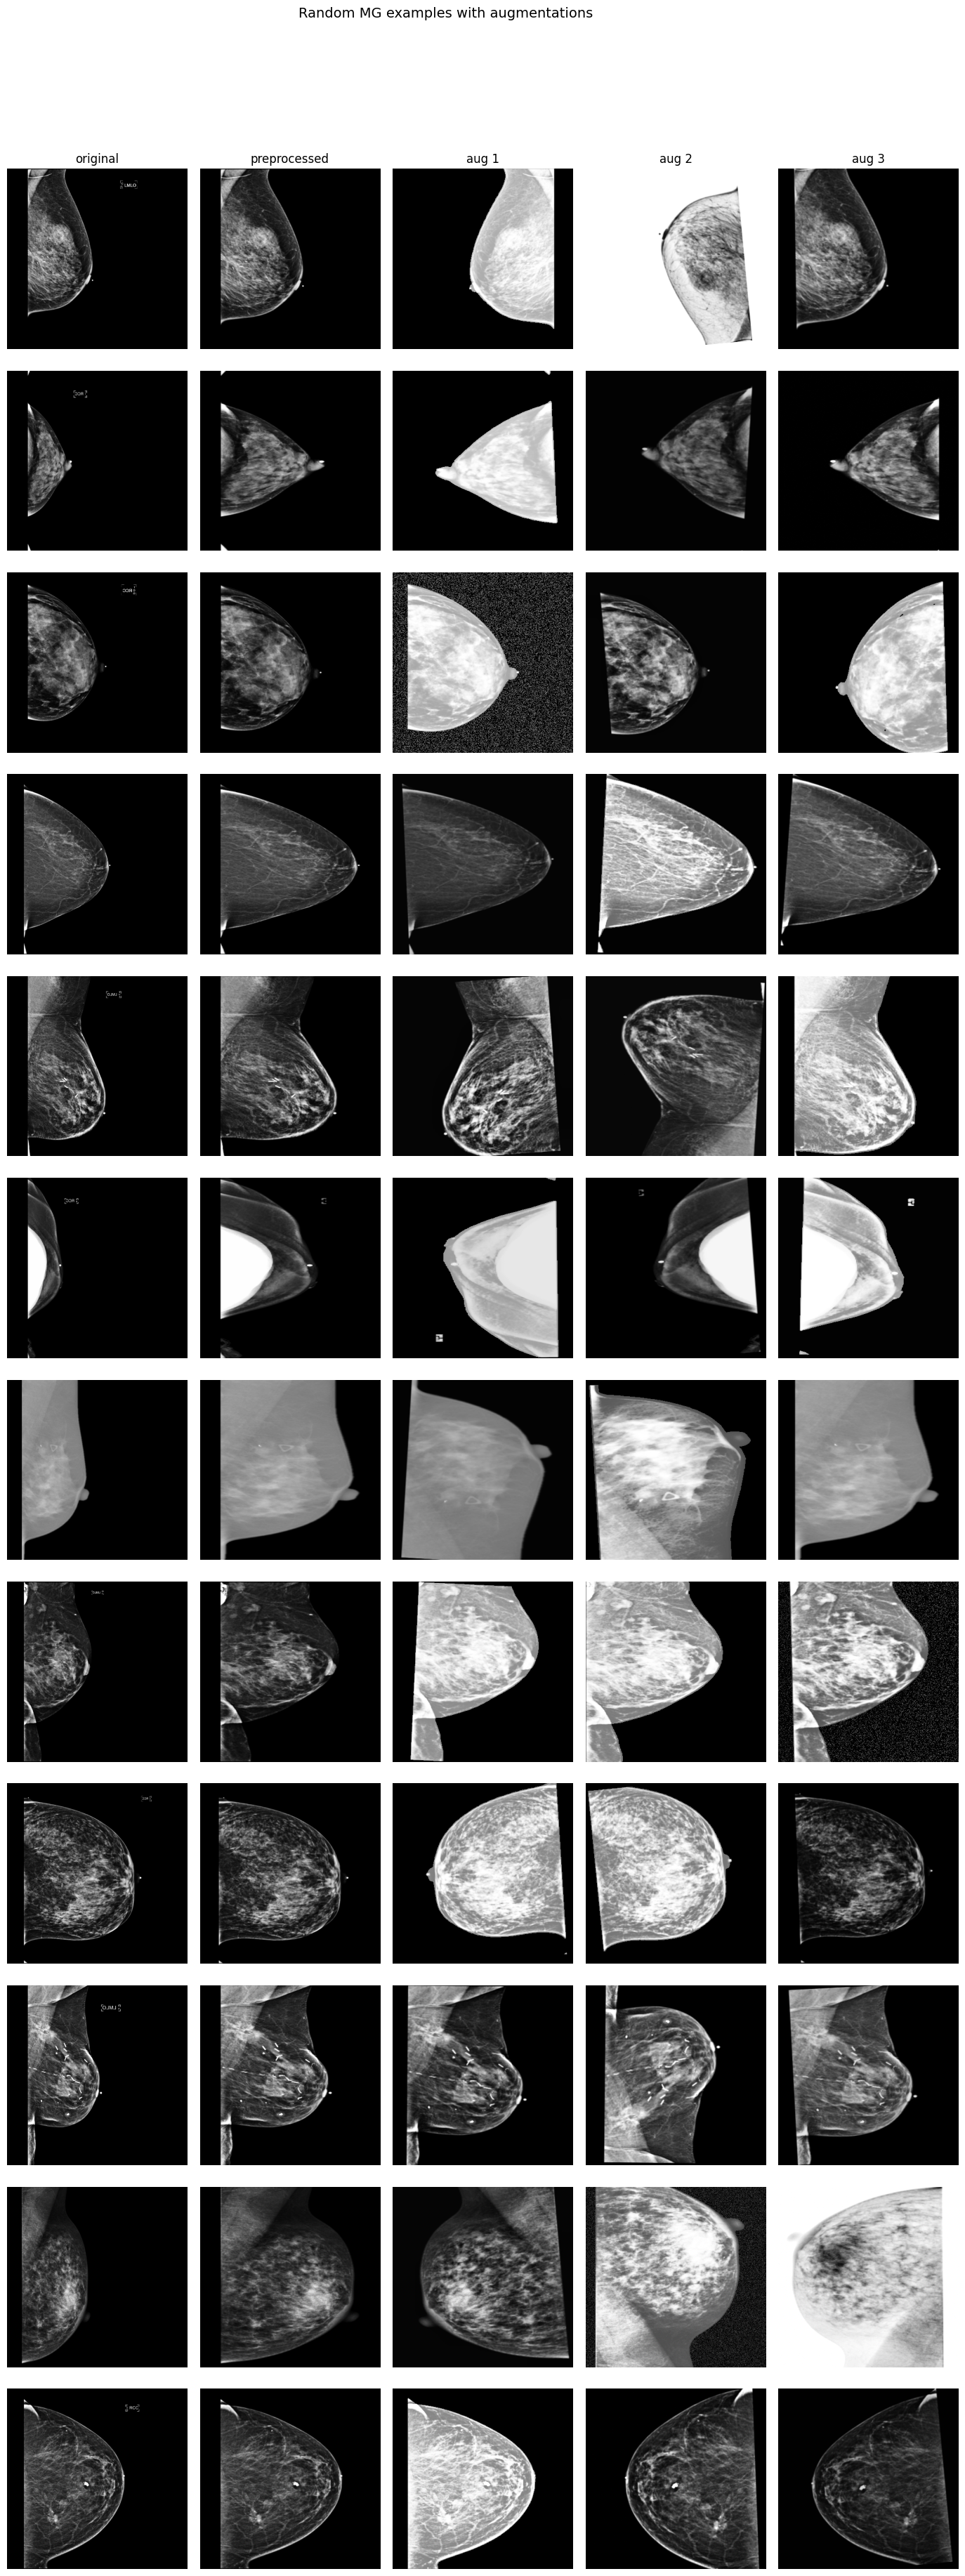

In [3]:
N_RANDOM_IMAGES = 12
N_AUGS_PER_IMAGE = 3

rows = sample_random_rows(N_RANDOM_IMAGES)
plot_rows_with_augmentations(rows, n_augs=N_AUGS_PER_IMAGE, title="Random MG examples with augmentations")

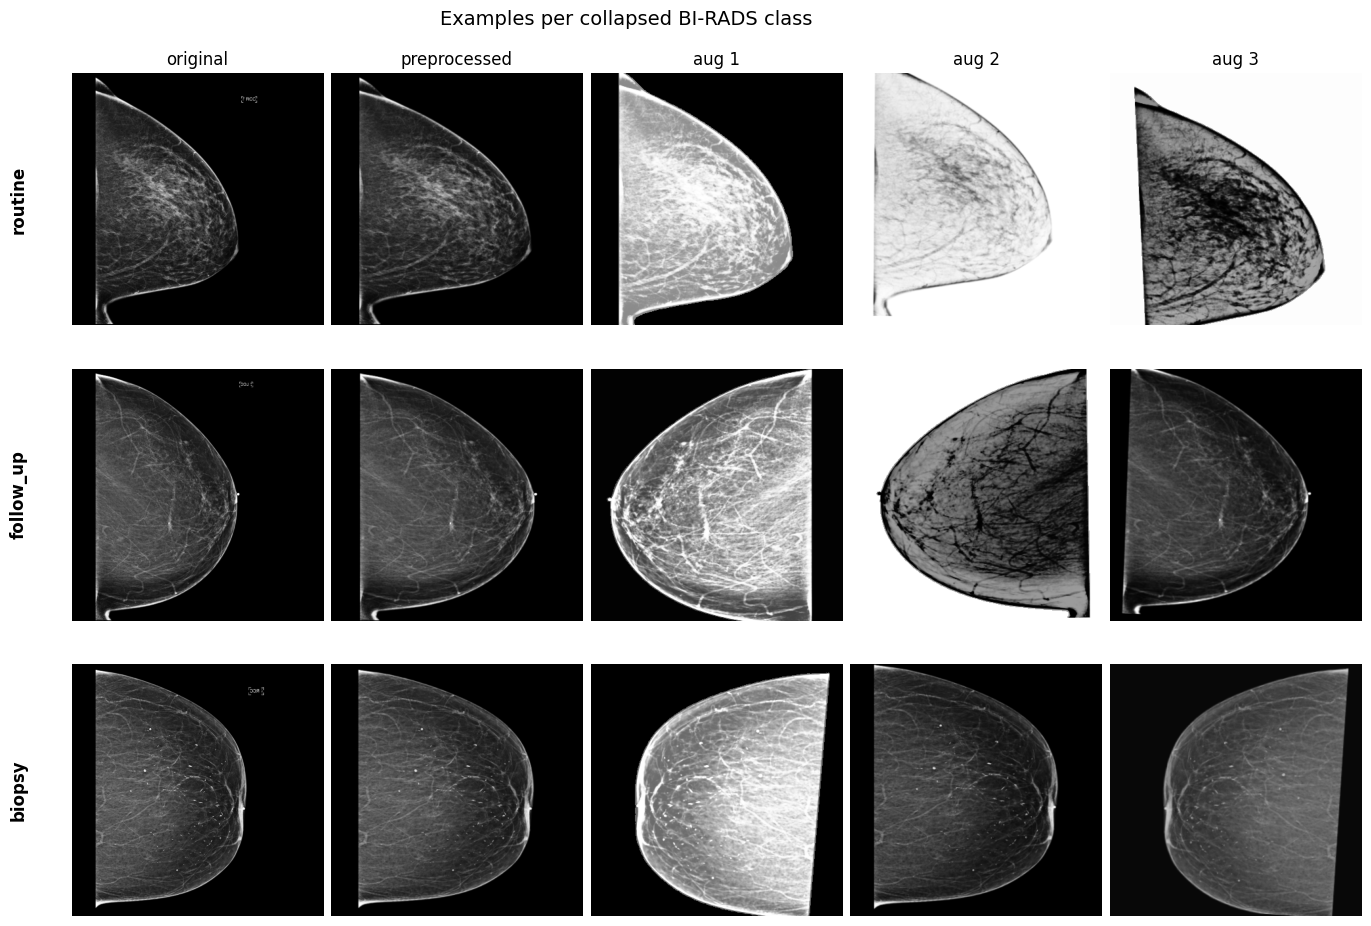

In [4]:
rows = sample_per_category(
    "collapsed_birads",
    categories=["routine", "follow_up", "biopsy"]
)
plot_rows_with_augmentations(
    rows,
    n_augs=N_AUGS_PER_IMAGE,
    title="Examples per collapsed BI-RADS class",
    categories=["routine", "follow_up", "biopsy"],
)

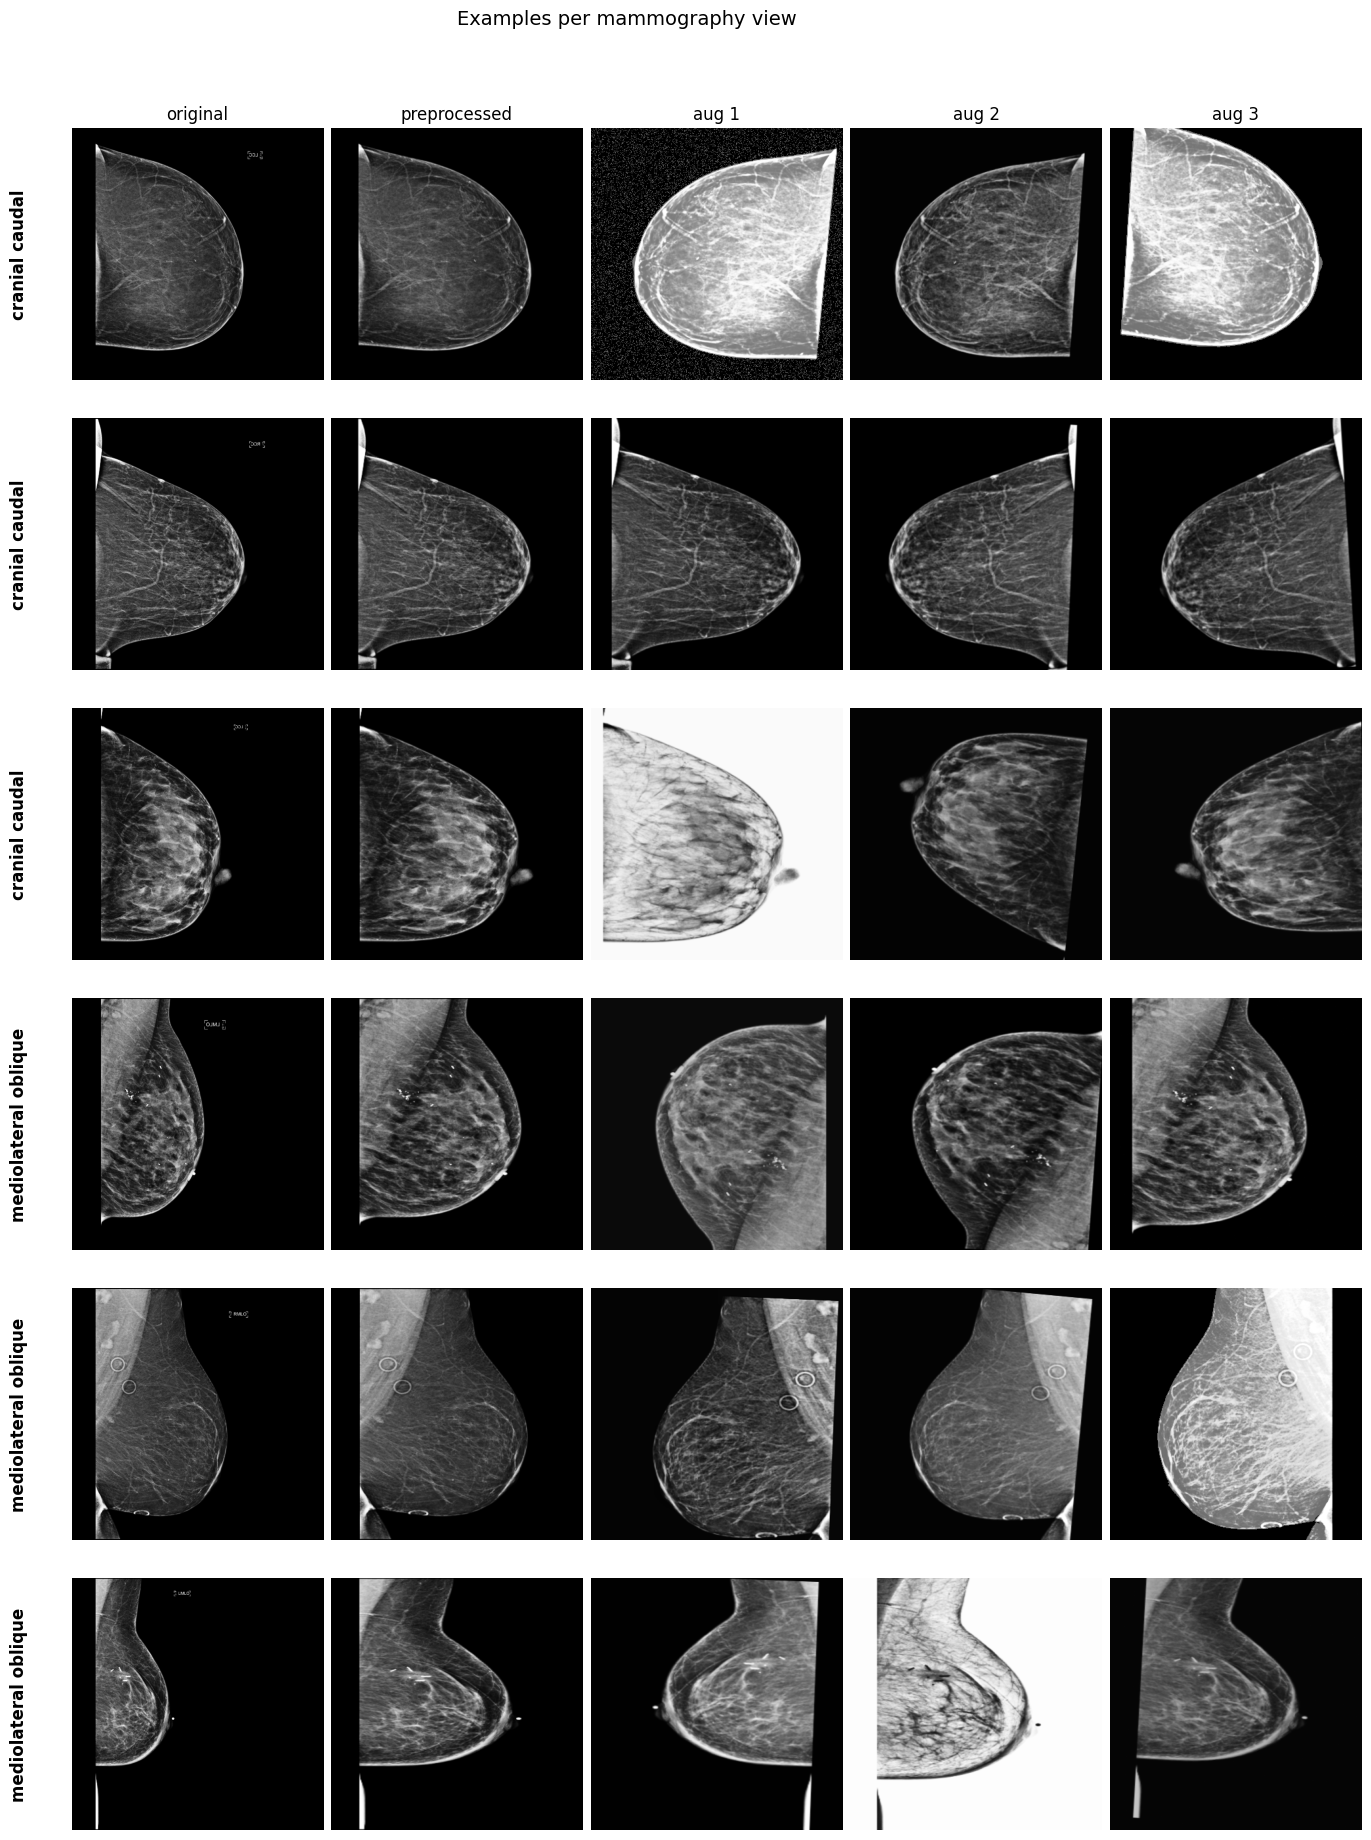

In [5]:
rows = sample_per_category(
    "view",
    categories=["cranial caudal", "mediolateral oblique"],
    nSamples=3
)
plot_rows_with_augmentations(
    rows,
    n_augs=N_AUGS_PER_IMAGE,
    title="Examples per mammography view",
    categories=["cranial caudal", "mediolateral oblique"],
)

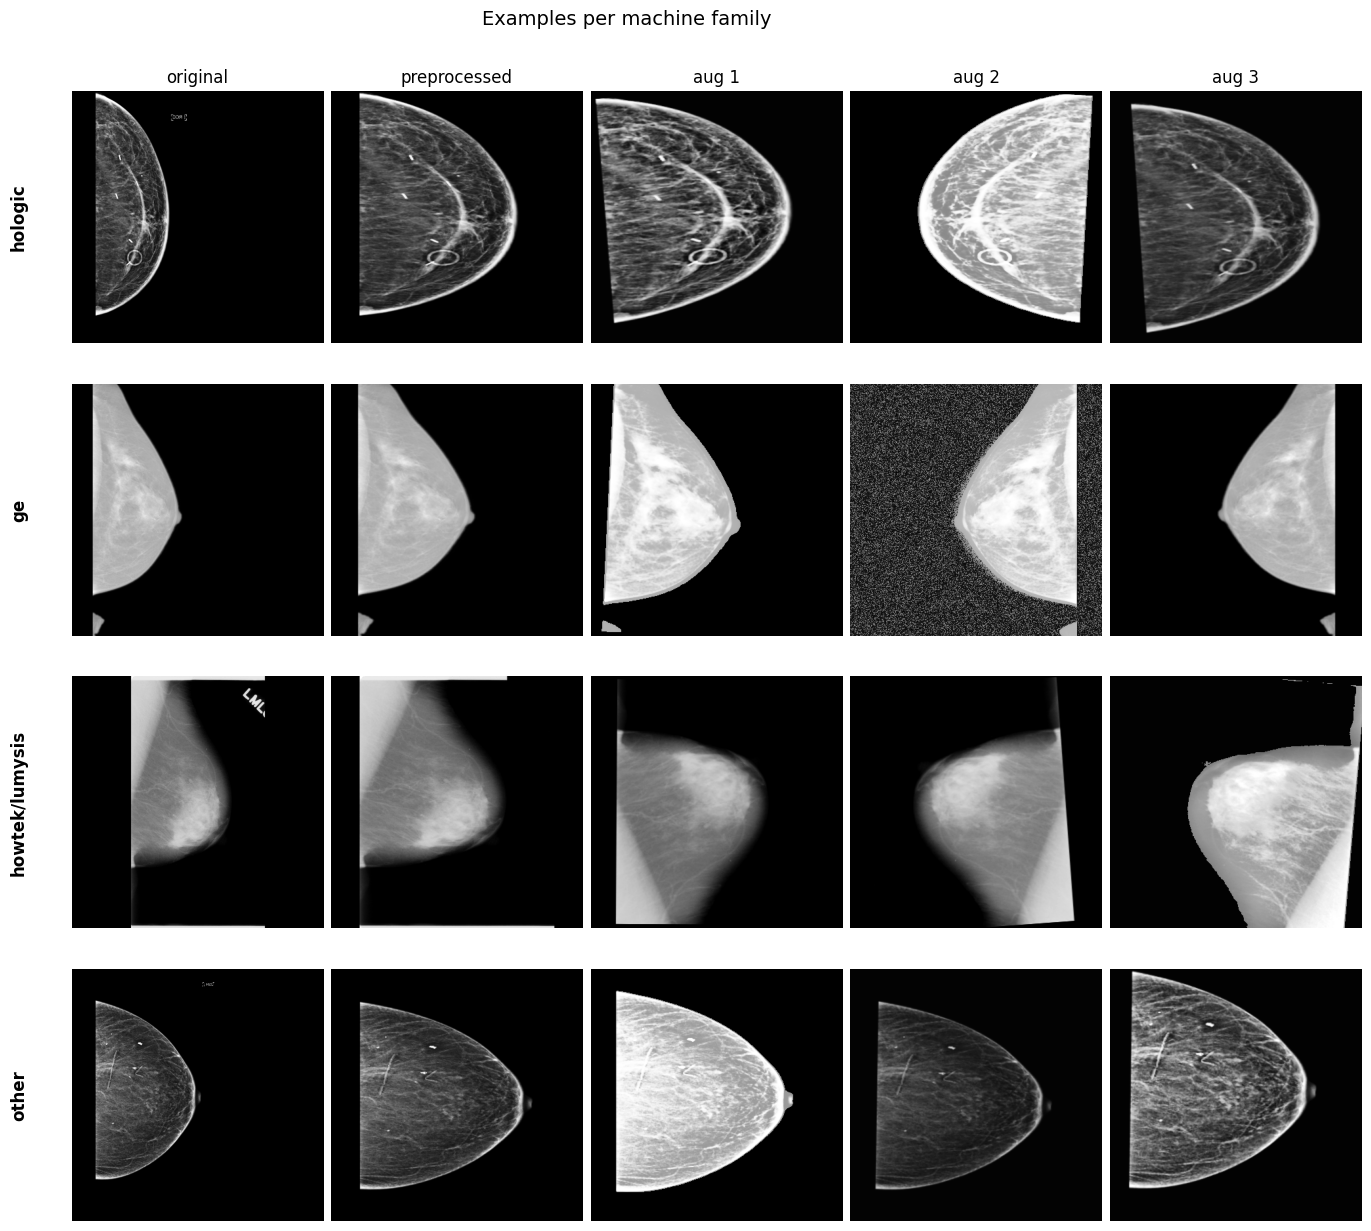

In [6]:
# Common families from the current MG metadata.
categories = ["hologic", "ge", "howtek/lumysis", "unknown", "other"]
categories = [c for c in categories if (df["machine_family"].astype(str) == c).any()]

rows = sample_per_category(
    "machine_family",
    categories=categories,
    seed=SEED
)
plot_rows_with_augmentations(
    rows,
    n_augs=N_AUGS_PER_IMAGE,
    title="Examples per machine family",
    categories=categories,
)

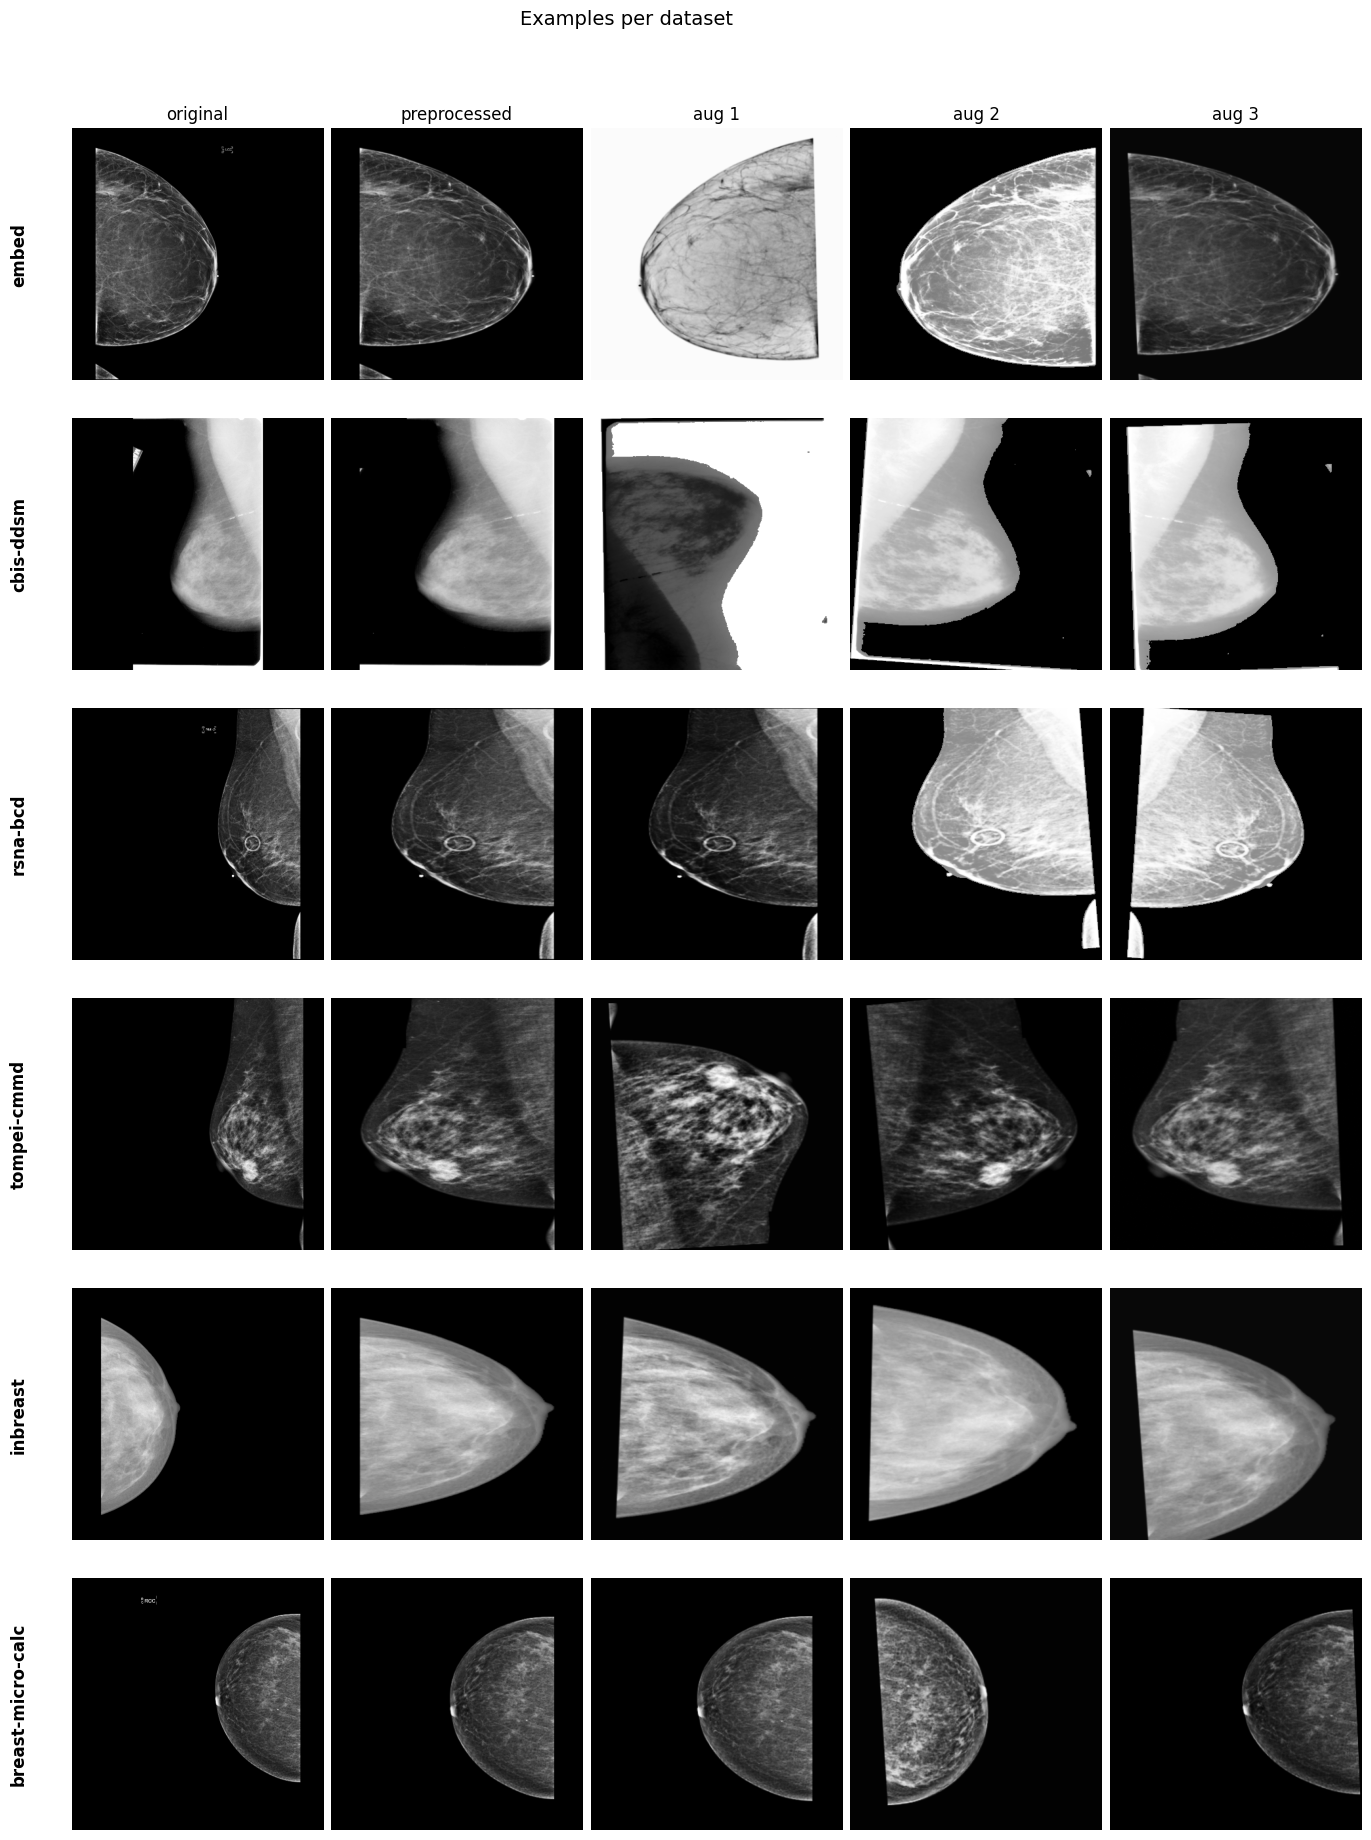

In [7]:
dataset_categories = [
    "embed",
    "cbis-ddsm",
    "rsna-bcd",
    "tompei-cmmd",
    "inbreast",
    "breast-micro-calc",
]

# Keep only datasets that are actually present in the currently loaded split.
dataset_categories = [
    c for c in dataset_categories
    if (df["dataset"].astype(str) == c).any()
]

rows = sample_per_category(
    "dataset",
    categories=dataset_categories,
)

plot_rows_with_augmentations(
    rows,
    n_augs=N_AUGS_PER_IMAGE,
    title="Examples per dataset",
    categories=dataset_categories,
)